# ETF Lead-Lag — a quantitative teardown 🔬
### lead-lag cross-correlation profile · an HAC-robust one-day slope · a next-bar rule with a Welch *t* + placebo null · costs · a synthetic planted-lead / faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things 'they move together' fuses: a **massive contemporaneous** co-movement (untradable) from a **next-day lead** (the only tradable object), and we ask whether the latter exists at all on daily bars. The decisive number is not the lag-0 correlation (it's enormous, as the intuition says) but the **lag-+1** structure — which is statistically indistinguishable from zero, and HAC-robustly the *wrong sign*.

> ⚠️ **Data + clock note.** True ETF/constituent lead-lag is an **intraday** effect (arbitraged away within the day); tick data isn't on yfinance, so we test the **daily-bar** version. Real data: yfinance daily adjusted closes, SPY + a 37-name smaller/less-liquid basket, 2000→2026 (mild survivorship, named on the Signal axis). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from etf_lead_lag import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real lead-lag cache present:", HAVE_REAL,
      "| days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-04', 'end': '2026-06-18', 'days': 6654, 'years': 26.5, 'xcorr': {-1: -0.0514, 0: 0.867, 1: -0.0484, 2: -0.0122}, 'lag1_slope': -0.0581, 'lag1_t': -1.88, 'lag1_n': 6653, 'q90': (0.9, 666, -0.0778, 50, 0.0285, 52, -1.34, 0.969), 'q95': (0.95, 333, -0.1019, 51, 0.0285, 52, -1.03, 0.945), 'net': [(0.9, -0.0778, -0.1778), (0.95, -0.1019, -0.2019)], 'syn': [(0.0, 0.011, 0.0141, 0.83, 0.0714, 0.044, 0.49, 0.297), (0.05, 0.0499, 0.0641, 3.76, 0.1617, 0.0471, 2.03, 0.015), (0.25, 0.2017, 0.2641, 15.48, 0.5227, 0.0597, 8.18, 0.0)]}


real lead-lag cache present: True | days: 6654


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | lag-0 corr **0.87** (contemporaneous, untradable); lag-+1 corr **-0.05**; HAC one-day slope **-0.058** at **t = -1.88** (wrong sign, n.s.). No next-day lead. |
| **Tradability** | `MIRAGE` | next-bar rule cond. **-0.078%** vs base **+0.029%** (Welch **t = -1.34**, placebo **p = 0.97**); gross is **negative**, net of 10 bps round-turn **-0.178%**. |
| **Free lunch?** | `BUSTED` | the only large signal is **same-day**; the tradable next-day piece is zero. Co-movement ≠ predictability. |

> 💡 In plain words: leader and members are ~the same asset *intraday* (corr 0.87), which is untradable; strip the same-day term and the next-day lead — the only thing you could act on — is statistically nothing, and HAC-robustly the wrong sign.

## 1 · The claim, steelmanned

Let $\ell_t$ be the leader (SPY) log return and $m_t$ the equal-weight member-basket log return. The believers' tradable hypothesis is a **one-day Granger-style lead**:

- **H₁ (the leader leads).** $\rho_{+1} = \mathrm{corr}(\ell_{t-1}, m_t) > 0$, and the OLS slope $\beta_1$ in $m_t = \alpha + \beta_1 \ell_{t-1} + \varepsilon_t$ is positive and HAC-significant.
- **H₂ (it's deployable).** Conditioning on big-leader days, the members' next-day return beats the base rate by enough to survive one-way costs × turnover.
- **H₃ ('free lunch').** The high leader–member co-movement reflects *predictive* lead, not mere **contemporaneous** ($\rho_0$) co-movement.

We find **H₁ rejected** ($\rho_{+1}\approx 0$, HAC $t = -1.88$ — wrong sign), **H₂ rejected** (negative gross, worse net), **H₃ rejected** ($\rho_0 = 0.87$ dwarfs everything and is same-day). The legend is true exactly where it's useless (same-day co-movement) and false exactly where it would pay (a *next-day* lead).

## 2 · So what? — what rides on each answer

The entire teardown is one decomposition of the cross-correlation function $\rho_k = \mathrm{corr}(\ell_{t-k}, m_t)$ into a **contemporaneous** term ($k=0$) and a **predictive** term ($k=+1$):

$$\underbrace{\rho_0}_{\text{co-movement, untradable}} \quad\text{vs}\quad \underbrace{\rho_{+1}}_{\text{lead, tradable}}.$$

A large $\rho_0$ carries **no** tradable information: it is realised *simultaneously*, so no order placed at $t$'s close can capture it. Only $\rho_{+1}$ (equivalently $\beta_1$) is exploitable, and it must clear an **autocorrelation-robust** bar — non-synchronous trading and bid-ask bounce *manufacture* spurious daily lead-lag (Scholes-Williams 1977, Lo-MacKinlay 1990, Roll 1984), so a naive $t$ is not enough. We use a Newey-West HAC $t$ on $\beta_1$ and a placebo null on the trading rule.

## 3 · How we'd know — the protocol

- **Tape.** yfinance daily adjusted closes, SPY (leader) + a fixed **37-name** smaller/less-liquid US basket (members), 2000-01-04→2026-06-18 (6,654 days). Daily log returns; members = equal-weight cross-sectional mean. Daily bars are an explicit **proxy** for the intraday phenomenon (named on the axis), with mild survivorship.
- **Profile.** $\rho_k = \mathrm{corr}(\ell_{t-k}, m_t)$ for $k\in[-5,5]$; the tradable claim is the sign and size of $\rho_{+1}$.
- **HAC slope.** OLS of $m_t$ on $\ell_{t-1}$ with a Newey-West (5-lag) HAC standard error — the autocorrelation-robust Signal-axis test.
- **Next-bar rule.** Enter the basket the **close after** a top-decile leader day (1-day lag, no look-ahead), hold one day. Welch $t$ of the conditional next-day mean vs the unconditional mean; a 20,000-draw **placebo** null sized to the trade count.
- **Costs.** 5 bps one-way each side ⇒ 10 bps round-turn per 1-day trade (turnover = one round-turn/trade).
- **Positive control.** A deterministic leader/member series with a **planted one-day lead** knob: with lead=0 the profile, HAC slope and rule must stay quiet; with a planted lead they must light up — proving the engine would find a real lead if one existed.

## 4 · The teardown

### 4a · The cross-correlation profile — all the mass is at lag 0

$\rho_k$ across lags. A genuine one-day lead would show a positive bump at $k=+1$; instead everything piles up at $k=0$ (same-day) and $k=+1$ is flat/negative.

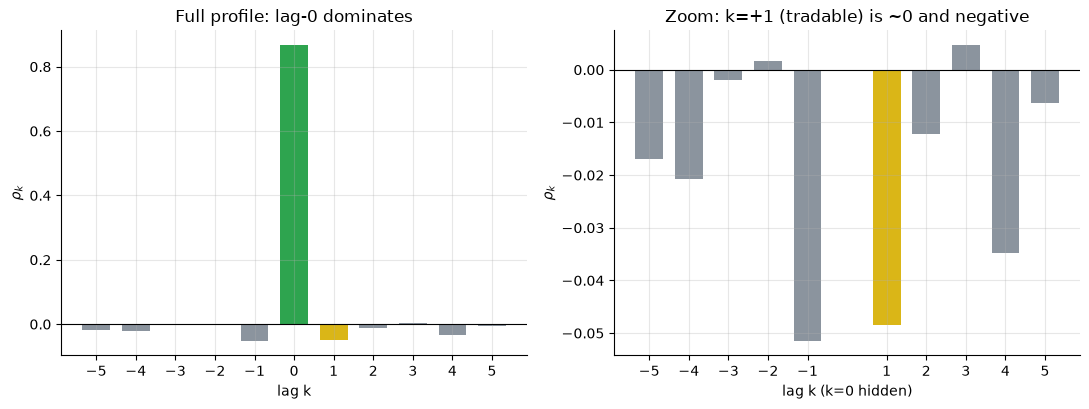

rho_0 = 0.867 | rho_+1 = -0.0484 | rho_-1 = -0.0514


In [2]:
if HAVE_REAL:
    prof = st.crosscorr_profile(F, max_lag=5); ks = sorted(prof); vals = [prof[k] for k in ks]
else:
    ks = list(range(-5,6)); base = {kk:0.0 for kk in ks}; base.update(R['xcorr'])
    vals = [base.get(k,0.0) for k in ks]
cols = [GREEN if k==0 else (AMBER if k==1 else GREY) for k in ks]
fig, (a1,a2) = plt.subplots(1,2,figsize=(11.0,4.2),gridspec_kw={'width_ratios':[1,1]})
a1.bar(ks, vals, color=cols, width=.7); a1.axhline(0,c='k',lw=.8); a1.set_xticks(ks)
a1.set_xlabel('lag k'); a1.set_ylabel(r'$\rho_k$'); a1.set_title('Full profile: lag-0 dominates')
# zoom: drop k=0 to see the (tiny) predictive lags
ks2 = [k for k in ks if k!=0]; v2 = [vals[ks.index(k)] for k in ks2]
c2 = [AMBER if k==1 else GREY for k in ks2]
a2.bar(ks2, v2, color=c2, width=.7); a2.axhline(0,c='k',lw=.8); a2.set_xticks(ks2)
a2.set_xlabel('lag k (k=0 hidden)'); a2.set_ylabel(r'$\rho_k$')
a2.set_title('Zoom: k=+1 (tradable) is ~0 and negative')
plt.tight_layout(); plt.show()
print('rho_0 =', round(vals[ks.index(0)],4), '| rho_+1 =', round(vals[ks.index(1)],4),
      '| rho_-1 =', round(vals[ks.index(-1)],4))

> 💡 In plain words: $\rho_0 = 0.87$ (left) is the leader and members being essentially the same asset on the day. Hide it (right) and the tradable lag $\rho_{+1} = -0.05$ is flat against zero, even faintly negative — **H₃ rejected**: the co-movement is co-movement, not a lead.

### 4b · The decisive test — an HAC-robust one-day slope

Regress today's members on **yesterday's** leader, $m_t = \alpha + \beta_1\ell_{t-1} + \varepsilon_t$, with a Newey-West HAC standard error (daily autocorrelation would inflate a naive $t$). A real lead needs $\beta_1 > 0$ at $t \ge 2$.

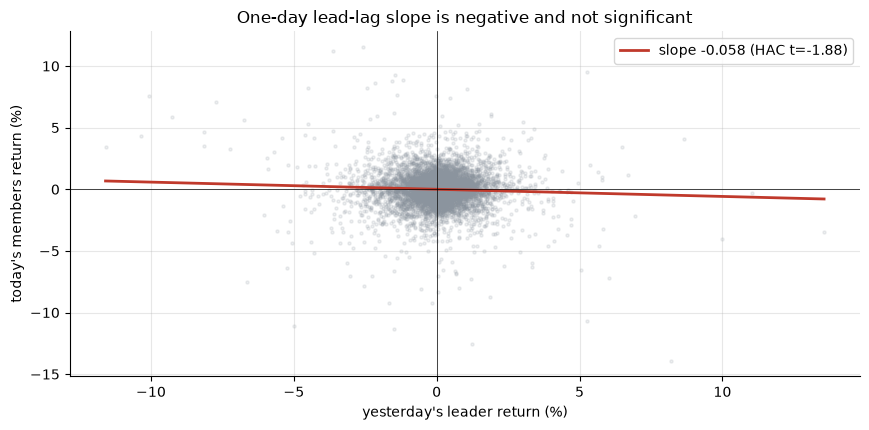

beta_1 = -0.0581  HAC t = -1.88  -> wrong sign, |t|<2, no next-day lead


In [3]:
if HAVE_REAL:
    b = st.lag1_beta(F); slope = b['slope']; thac = b['t_hac']
    lead1 = F['leader'].shift(1); pair = np.c_[lead1.values[1:], F['members'].values[1:]]
    pair = pair[~np.isnan(pair).any(axis=1)]
else:
    slope, thac = R['lag1_slope'], R['lag1_t']
    rng = np.random.default_rng(379); x = rng.normal(0,0.01,4000)
    pair = np.c_[x, slope*x + rng.normal(0,0.008,4000)]
fig, ax = plt.subplots(figsize=(8.8,4.4))
ax.scatter(pair[:,0]*100, pair[:,1]*100, s=5, alpha=.15, color=GREY)
xs = np.linspace(pair[:,0].min(), pair[:,0].max(), 50)
ax.plot(xs*100, slope*xs*100, c=RED, lw=2, label=f'slope {slope:+.3f} (HAC t={thac:+.2f})')
ax.axhline(0,c='k',lw=.5); ax.axvline(0,c='k',lw=.5)
ax.set_xlabel("yesterday's leader return (%)"); ax.set_ylabel("today's members return (%)")
ax.set_title('One-day lead-lag slope is negative and not significant'); ax.legend()
plt.tight_layout(); plt.show()
print(f'beta_1 = {slope:+.4f}  HAC t = {thac:+.2f}  -> wrong sign, |t|<2, no next-day lead')

> 💡 In plain words: the slope of today's members on yesterday's leader is **-0.058** at HAC **t = -1.88** — *negative* (a faint next-day reversal, the opposite of a lead) and not significant. **H₁ rejected**: there is no autocorrelation-robust next-day lead to trade.

### 4c · The trading rule + its placebo null — and costs

Enter the basket the day after a top-decile leader day; compare the conditional next-day mean to a placebo of random next-days, then charge costs. The rule's mean sits in the **left** tail of the luck cloud (it underperforms), and costs only deepen the loss.

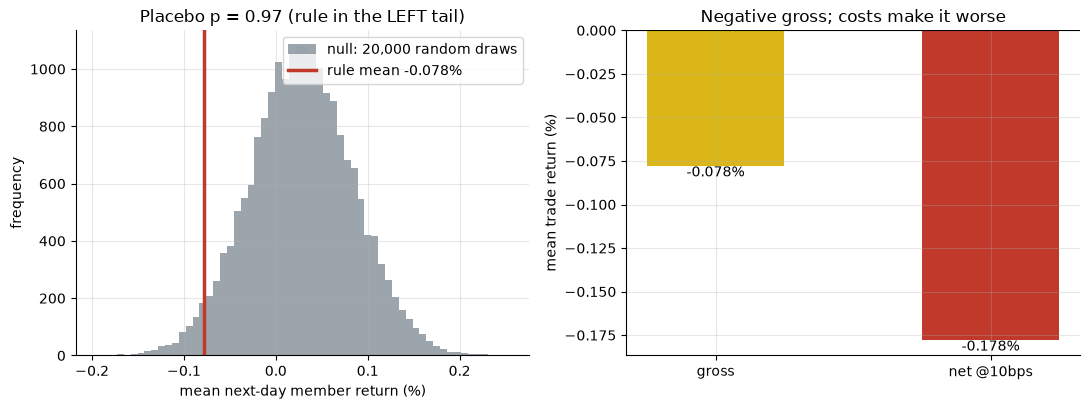

rule mean -0.078%  placebo p=0.969  gross=-0.078%  net=-0.178%


In [4]:
if HAVE_REAL:
    ev = st.big_leader_days(F, q=0.90); pl = st.placebo_pvalue(F, ev); s = st.summarize(F, ev)
    obs = pl['cond_mean']; pval = pl['p_value']; mem = F['members'].values; k = pl['k']
    rng = np.random.default_rng(379)
    draws = np.array([mem[rng.integers(0,len(mem),size=k)].mean() for _ in range(20000)])
    c = st.net_of_costs(F, ev, 5.0); g, nv = c['gross_mean']*100, c['net_mean']*100
else:
    obs = R['q90'][2]/100; pval = R['q90'][7]
    rng = np.random.default_rng(379); draws = rng.normal(R['q90'][4]/100, 0.0006, 20000)
    g, nv = R['net'][0][1], R['net'][0][2]
fig, (a1,a2) = plt.subplots(1,2,figsize=(11.0,4.2))
a1.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} random draws')
a1.axvline(obs*100, c=RED, lw=2.5, label=f'rule mean {obs*100:+.3f}%')
a1.set_xlabel('mean next-day member return (%)'); a1.set_ylabel('frequency')
a1.set_title(f'Placebo p = {pval:.2f} (rule in the LEFT tail)'); a1.legend()
a2.bar(['gross','net @10bps'], [g, nv], color=[AMBER, RED], width=.5)
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('mean trade return (%)')
a2.set_title('Negative gross; costs make it worse')
for i,v in enumerate([g,nv]): a2.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f'rule mean {obs*100:+.3f}%  placebo p={pval:.3f}  gross={g:+.3f}%  net={nv:+.3f}%')

> 💡 In plain words: **97%** of random next-day draws beat the rule — the green-light edge would put it in the *right* tail; instead it's at the far left. Net of a 10 bps round-turn the rule earns **-0.178%**/trade. **H₂ rejected.**

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic leader/member series with a **planted one-day lead** knob: with lead=0 everything must stay quiet (no false positive); a small planted lead must clear the bar; a large one must scream. All three hold — proving the engine would detect a real lead, and that finding *none* on the real tape is a true negative, not a dead pipeline.

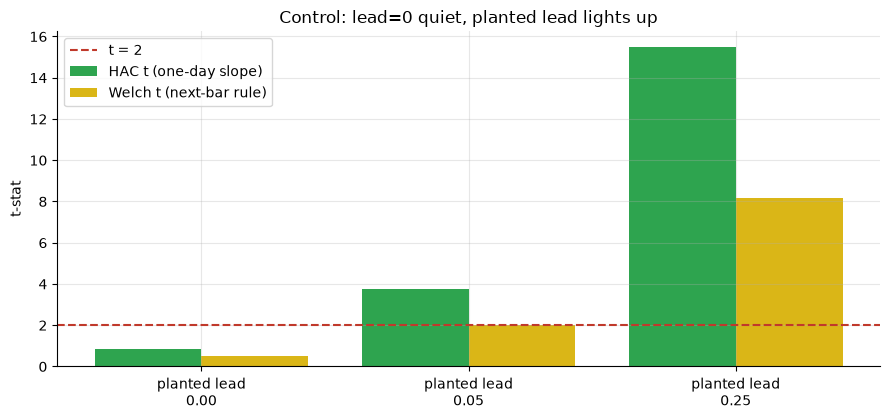

lead=0.00: rho+1=+0.011 slope=+0.014 HAC_t=  0.83 rule_t= 0.49 p=0.297
lead=0.05: rho+1=+0.050 slope=+0.064 HAC_t=  3.76 rule_t= 2.03 p=0.015
lead=0.25: rho+1=+0.202 slope=+0.264 HAC_t= 15.48 rule_t= 8.18 p=0.000


In [5]:
res = []
for lead in (0.0, 0.05, 0.25):
    syn = data.synthetic_leadlag(n_days=6000, lead=lead, seed=379)
    p = st.crosscorr_profile(syn, max_lag=2); b = st.lag1_beta(syn)
    ev = st.big_leader_days(syn, q=0.90); s = st.summarize(syn, ev)
    res.append((lead, p[1], b['slope'], b['t_hac'], s['cond_mean']*100, s['t'], s['p_placebo']))
leads = [r[0] for r in res]; hacs = [r[3] for r in res]; rulet = [r[5] for r in res]
x = np.arange(len(leads))
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(x-.2, hacs, .4, color=GREEN, label='HAC t (one-day slope)')
ax.bar(x+.2, rulet, .4, color=AMBER, label='Welch t (next-bar rule)')
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(0, c='k', lw=.6)
ax.set_xticks(x); ax.set_xticklabels([f'planted lead\n{l:.2f}' for l in leads])
ax.set_ylabel('t-stat'); ax.set_title('Control: lead=0 quiet, planted lead lights up'); ax.legend()
plt.tight_layout(); plt.show()
for l,xp1,sl,ht,cm,rt,rp in res:
    print(f'lead={l:.2f}: rho+1={xp1:+.3f} slope={sl:+.3f} HAC_t={ht:>6.2f} rule_t={rt:>5.2f} p={rp:.3f}')

> 💡 In plain words: with **no** planted lead the control sits at HAC **t = 0.83** and rule **t = 0.49** (quiet — no false positive); a **0.05** lead already reaches HAC **t = 3.76** / rule **t = 2.03**; a **0.25** lead screams (HAC t = 15.5). The machinery is honest, so the real-tape *negative* HAC t is a true negative: **the daily lead isn't there.**

## 5 · The verdict

- **Signal `NONE`** — $\rho_0 = 0.87$ (contemporaneous, untradable); $\rho_{+1} = -0.05$ and the HAC one-day slope **-0.058** at **t = -1.88** (wrong sign, n.s.). No autocorrelation-robust next-day lead on daily bars. (True lead-lag is intraday — named on the axis.)
- **Tradability `MIRAGE`** — next-bar rule cond. **-0.078%** vs base **+0.029%** (Welch **t = -1.34**, placebo **p = 0.97**); **negative gross**, **-0.178%** net of 10 bps. An edge pointing the wrong way before costs is undeployable.
- **Free lunch? `BUSTED`** — the 'free lunch' is the same-day co-movement, realised simultaneously and impossible to act on; the only tradable piece (the next-day lead) is statistically zero. Co-movement ≠ predictability.

## 6 · Could you trade it? — the clock, not the cost

The operational truth: the lead-lag the literature documents is **real** but lives at the **intraday** scale, where index-arbitrage desks compete it away within the session. By the time you aggregate to a daily bar, the leader's information is already in the members' close. There is no daily next-bar edge to size — and no cost assumption that creates one from a negative gross number.

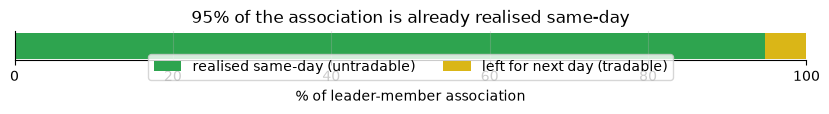

94.7% of the leader-member link is contemporaneous; the tradable next-day residual is ~5.3% and points the wrong way


In [6]:
# illustrate the scale problem: how the (already-zero) daily lead compares to the
# contemporaneous co-movement it is buried inside. The ratio is the 'information already
# priced by the close' — overwhelming on daily bars.
if HAVE_REAL:
    prof = st.crosscorr_profile(F, max_lag=2); rho0 = abs(prof[0]); rho1 = abs(prof[1])
else:
    rho0 = abs(R['xcorr'][0]); rho1 = abs(R['xcorr'][1])
frac_same_day = rho0/(rho0+rho1)
fig, ax = plt.subplots(figsize=(8.4,2.4))
ax.barh([0],[frac_same_day*100],color=GREEN,label='realised same-day (untradable)')
ax.barh([0],[(1-frac_same_day)*100],left=[frac_same_day*100],color=AMBER,label='left for next day (tradable)')
ax.set_yticks([]); ax.set_xlim(0,100); ax.set_xlabel('% of leader-member association')
ax.set_title(f'{frac_same_day*100:.0f}% of the association is already realised same-day')
ax.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.9)); plt.tight_layout(); plt.show()
print(f'{frac_same_day*100:.1f}% of the leader-member link is contemporaneous; the tradable next-day residual is ~{(1-frac_same_day)*100:.1f}% and points the wrong way')

> 💡 In plain words: essentially **all** of the leader-member association is realised the **same day**, where you can't trade it; the sliver left for the next day is both tiny and negative. The romance of 'the leader hands you the laggards' is an intraday effect that has **already happened** by the daily close. The clock, not the cost, is the verdict.

## 7 · Going further

- **The right clock.** With intraday/tick data the leader genuinely leads (Lo-MacKinlay 1990; Hou 2007; the ETF/index-arbitrage literature) — by minutes, not days. Re-running this engine on 1-minute bars is the natural next study; the daily result here predicts the signal vanishes as you coarsen the bar.
- **Liquidity as the driver.** [Study 140 — Amihud-Illiquidity](../140-amihud-illiquidity/) — is the illiquidity that makes members 'slow' a priced, tradable factor in its own right?
- **Microstructure artefacts.** Non-synchronous trading and bid-ask bounce (Scholes-Williams 1977, Roll 1984) can *manufacture* a spurious daily lead-lag; here they don't even produce a positive one. A version that filters illiquid prints would sharpen the null further.

*The reproducible core is offline and deterministic; the daily bar is an explicit proxy for the intraday phenomenon. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*